In [1]:
import pandas as pd
from CosinorPy import file_parser, cosinor, cosinor1
import numpy as np

In [2]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples
# trimmed_transcriptome = transcriptome.drop(index=all_unsable)
# trimmed_metadata = metadata.drop(index=all_unsable)
## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [3]:
circadian_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 1")
]
circadian_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 1")
]
circadian_metadata["Time Since Start"] = (
    circadian_metadata["Date and Time"]
    - circadian_metadata.sort_values(by="Date and Time")["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)


circadian_metadata_2 = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 2")
]
circadian_transcriptome_2 = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 2")
]
circadian_metadata_2["Time Since Start"] = (
    circadian_metadata_2["Date and Time"]
    - circadian_metadata_2.sort_values(by="Date and Time")["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)

# lines below for when we finish all circadian data, until then we only use weekend 1
##circadian_metadata = trimmed_metadata.loc[trimmed_metadata['Experiment Type'].str.contains('Circadian')]

##circadian_transcriptome = trimmed_transcriptome.loc[trimmed_metadata['Experiment Type'].str.contains('Circadian')]


# circadian_expt_2_start_time = circadian_metadata.loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2']['Date and Time'].min()
# circadian_metadata['Time Since Start'] = (circadian_metadata['Date and Time'] - circadian_metadata['Date and Time'].iloc[0])/pd.Timedelta(hours=1)
# circadian_metadata['Time Since Start'].loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2'] = (circadian_metadata.loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2']['Date and Time'] - circadian_expt_2_start_time)/pd.Timedelta(hours=1)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_52067/469193494.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata["Time Since Start"] = (
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_52067/469193494.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata_2["Time Since Start"] = (


In [4]:
## Filter genes down to speed up fitting regression and not bother analyzing zeros.
trimmed_circadian_transcriptome = circadian_transcriptome.loc[
    :, (circadian_transcriptome > 1).sum() > 20
]
trimmed_circadian_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
B250508004_n01_LICRNA03_B05,0.397484,3.914962,0.528310,3.953698,40.794727,1.797838,1.465764,13.426630,50.427659,751.295222,...,261.218299,20.331917,3.257055,60.688241,47.487560,7.765663,7.125035,0.000000,0.000000,0.271092
B250508004_n01_LICRNA03_C05,0.242429,4.428221,0.644440,3.014240,17.650893,1.824204,1.620340,10.899454,43.328510,707.648911,...,202.396203,0.000000,0.993252,108.967489,0.000000,4.262705,4.528588,5.683607,5.465007,1.240060
B250508004_n01_LICRNA03_D05,1.673381,6.023319,1.853456,2.654170,54.553650,0.495411,4.088131,10.668133,39.628764,546.454230,...,115.415643,7.003306,0.000000,108.815011,3.869407,3.923148,4.262576,0.000000,5.130271,3.423839
B250508004_n01_LICRNA03_E05,0.306973,2.902550,0.054401,2.195151,36.827954,0.060587,0.905597,12.384698,53.128935,552.554405,...,139.396819,5.138887,1.006157,23.824806,5.678587,1.439364,4.239898,0.000000,0.442881,2.763579
B250508004_n01_LICRNA03_F05,0.731436,8.981825,0.185176,3.511319,34.519120,0.360907,1.252293,14.317252,52.002506,646.797526,...,169.208243,2.915382,1.712433,19.709433,0.000000,2.449730,2.484234,0.000000,4.145698,0.213795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,7.860235,3.199519,39.201659,1.057777,0.340746,10.691515,41.791184,735.130580,...,168.469799,9.281249,0.000000,40.986862,0.000000,0.000000,4.602930,22.529946,1.333133,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,1.577446,3.055581,29.564231,12.872063,1.199338,12.899944,63.214495,575.866112,...,201.254114,0.000000,8.976954,35.701763,69.663625,0.000000,6.899039,1.605254,3.951394,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,1.641699,5.632121,48.940407,24.612749,5.452616,11.798065,50.626712,722.137699,...,98.678964,0.000000,1.167825,38.226127,0.000000,0.000000,7.502750,0.000000,1.799150,0.145801


In [5]:
trimmed_circadian_transcriptome_2 = circadian_transcriptome_2.loc[
    :, (circadian_transcriptome_2 > 1).sum() > 20
]
trimmed_circadian_transcriptome_2

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCp081,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCp088,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
B2449500127_n01_LICRNA04_C07,0.369734,5.032079,2.293318,1.259021,23.750115,0.243247,1.249811,12.782414,42.792364,518.390577,...,493.989825,130.697200,0.000000,0.000000,12.881989,0.000000,5.778798,0.279057,2.667137,3.025989
B2449500127_n01_LICRNA04_D07,0.000000,7.451890,2.867837,1.926605,23.558990,0.380231,0.000000,13.051683,36.361155,672.418492,...,552.948569,143.955638,0.000000,1.262882,20.367911,8.909376,0.000000,1.832069,5.280899,1.892027
B2449500127_n01_LICRNA04_E07,0.629969,6.656039,0.651243,2.907280,31.338727,2.745762,0.096795,14.386294,49.448987,636.251551,...,604.710033,160.370885,52.729929,3.441382,22.705770,50.984304,0.000000,2.615081,5.301787,0.644477
B2449500127_n01_LICRNA04_F07,0.402656,7.895757,2.854316,5.222927,37.193012,8.245217,0.000000,8.141649,38.178456,838.687245,...,455.668335,119.556438,5.617224,0.000000,34.770314,4.655370,11.800070,2.849112,5.809265,6.384911
B2449500127_n01_LICRNA04_G07,0.304598,4.418313,1.214553,5.117861,46.119998,2.630170,2.948491,11.013590,44.609410,709.073313,...,504.532264,137.004033,0.000000,12.479630,21.316629,56.346383,0.000000,4.827800,3.295902,0.623225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_G07,0.620785,7.781875,2.872592,3.449003,33.680234,0.000000,0.381535,14.439102,58.338653,612.626451,...,425.607903,169.207077,21.169395,4.521618,53.699446,0.000000,1.617107,8.589862,3.731784,7.197594
A2534491401_n01_LICRNA05_H07,0.000000,2.561732,2.535106,2.600397,37.505886,0.470562,0.627991,16.528305,50.760850,418.701771,...,617.991355,142.246134,26.608134,24.559935,114.289511,0.000000,0.000000,13.418790,3.931116,3.205647
A2534491401_n01_LICRNA05_A10,0.000000,0.000000,0.000000,0.000000,0.000000,0.293215,0.000000,0.000000,0.529054,2.343661,...,229.169651,0.187108,0.000000,19.477414,356.256463,13.740916,0.000000,25.564923,4.286696,64.440730


In [6]:
trimmed_circadian_transcriptome = trimmed_circadian_transcriptome.merge(
    right=circadian_metadata[["timepoint", "Time Since Start"]],
    left_index=True,
    right_index=True,
)
trimmed_circadian_transcriptome = trimmed_circadian_transcriptome.set_index(
    "timepoint", append=False
)
trimmed_circadian_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c1_t01,0.397484,3.914962,0.528310,3.953698,40.794727,1.797838,1.465764,13.426630,50.427659,751.295222,...,20.331917,3.257055,60.688241,47.487560,7.765663,7.125035,0.000000,0.000000,0.271092,0.0
c1_t01,0.242429,4.428221,0.644440,3.014240,17.650893,1.824204,1.620340,10.899454,43.328510,707.648911,...,0.000000,0.993252,108.967489,0.000000,4.262705,4.528588,5.683607,5.465007,1.240060,0.0
c1_t01,1.673381,6.023319,1.853456,2.654170,54.553650,0.495411,4.088131,10.668133,39.628764,546.454230,...,7.003306,0.000000,108.815011,3.869407,3.923148,4.262576,0.000000,5.130271,3.423839,0.0
c1_t01,0.306973,2.902550,0.054401,2.195151,36.827954,0.060587,0.905597,12.384698,53.128935,552.554405,...,5.138887,1.006157,23.824806,5.678587,1.439364,4.239898,0.000000,0.442881,2.763579,0.0
c1_t01,0.731436,8.981825,0.185176,3.511319,34.519120,0.360907,1.252293,14.317252,52.002506,646.797526,...,2.915382,1.712433,19.709433,0.000000,2.449730,2.484234,0.000000,4.145698,0.213795,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c1_t13,0.000000,8.339930,7.860235,3.199519,39.201659,1.057777,0.340746,10.691515,41.791184,735.130580,...,9.281249,0.000000,40.986862,0.000000,0.000000,4.602930,22.529946,1.333133,5.293749,48.0
c1_t09,0.000000,1.692107,1.577446,3.055581,29.564231,12.872063,1.199338,12.899944,63.214495,575.866112,...,0.000000,8.976954,35.701763,69.663625,0.000000,6.899039,1.605254,3.951394,3.222183,32.0
c1_t04,0.641335,5.972190,1.641699,5.632121,48.940407,24.612749,5.452616,11.798065,50.626712,722.137699,...,0.000000,1.167825,38.226127,0.000000,0.000000,7.502750,0.000000,1.799150,0.145801,12.0


In [7]:
trimmed_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.merge(
    right=circadian_metadata_2[["timepoint", "Time Since Start"]],
    left_index=True,
    right_index=True,
)
trimmed_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.set_index(
    "timepoint", append=False
)
trimmed_circadian_transcriptome_2

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCp088,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c2_t01,0.369734,5.032079,2.293318,1.259021,23.750115,0.243247,1.249811,12.782414,42.792364,518.390577,...,130.697200,0.000000,0.000000,12.881989,0.000000,5.778798,0.279057,2.667137,3.025989,0.0
c2_t01,0.000000,7.451890,2.867837,1.926605,23.558990,0.380231,0.000000,13.051683,36.361155,672.418492,...,143.955638,0.000000,1.262882,20.367911,8.909376,0.000000,1.832069,5.280899,1.892027,0.0
c2_t01,0.629969,6.656039,0.651243,2.907280,31.338727,2.745762,0.096795,14.386294,49.448987,636.251551,...,160.370885,52.729929,3.441382,22.705770,50.984304,0.000000,2.615081,5.301787,0.644477,0.0
c2_t01,0.402656,7.895757,2.854316,5.222927,37.193012,8.245217,0.000000,8.141649,38.178456,838.687245,...,119.556438,5.617224,0.000000,34.770314,4.655370,11.800070,2.849112,5.809265,6.384911,0.0
c2_t01,0.304598,4.418313,1.214553,5.117861,46.119998,2.630170,2.948491,11.013590,44.609410,709.073313,...,137.004033,0.000000,12.479630,21.316629,56.346383,0.000000,4.827800,3.295902,0.623225,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c2_t13,0.620785,7.781875,2.872592,3.449003,33.680234,0.000000,0.381535,14.439102,58.338653,612.626451,...,169.207077,21.169395,4.521618,53.699446,0.000000,1.617107,8.589862,3.731784,7.197594,48.0
c2_t13,0.000000,2.561732,2.535106,2.600397,37.505886,0.470562,0.627991,16.528305,50.760850,418.701771,...,142.246134,26.608134,24.559935,114.289511,0.000000,0.000000,13.418790,3.931116,3.205647,48.0
c2_t01,0.000000,0.000000,0.000000,0.000000,0.000000,0.293215,0.000000,0.000000,0.529054,2.343661,...,0.187108,0.000000,19.477414,356.256463,13.740916,0.000000,25.564923,4.286696,64.440730,0.0


In [8]:
cosinor_formatted_circadian_transcriptome = trimmed_circadian_transcriptome.melt(
    id_vars="Time Since Start", var_name="Gene", value_name="y"
)
cosinor_formatted_circadian_transcriptome = (
    cosinor_formatted_circadian_transcriptome.rename(
        columns={"Gene": "test", "Time Since Start": "x"}
    )
)
cosinor_formatted_circadian_transcriptome = cosinor_formatted_circadian_transcriptome[
    ["test", "x", "y"]
]
cosinor_formatted_circadian_transcriptome

,test,x,y
0,AT1G01010,0.0,0.397484
1,AT1G01010,0.0,0.242429
2,AT1G01010,0.0,1.673381
3,AT1G01010,0.0,0.306973
4,AT1G01010,0.0,0.731436
...,...,...,...
1792747,ArthCp085,48.0,5.293749
1792748,ArthCp085,32.0,3.222183
1792749,ArthCp085,12.0,0.145801
1792750,ArthCp085,32.0,3.821523


In [9]:
cosinor_formatted_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.melt(
    id_vars="Time Since Start", var_name="Gene", value_name="y"
)
cosinor_formatted_circadian_transcriptome_2 = (
    cosinor_formatted_circadian_transcriptome_2.rename(
        columns={"Gene": "test", "Time Since Start": "x"}
    )
)
cosinor_formatted_circadian_transcriptome_2 = (
    cosinor_formatted_circadian_transcriptome_2[["test", "x", "y"]]
)
cosinor_formatted_circadian_transcriptome_2

,test,x,y
0,AT1G01010,0.0,0.369734
1,AT1G01010,0.0,0.000000
2,AT1G01010,0.0,0.629969
3,AT1G01010,0.0,0.402656
4,AT1G01010,0.0,0.304598
...,...,...,...
1776627,ArthCp085,48.0,7.197594
1776628,ArthCp085,48.0,3.205647
1776629,ArthCp085,0.0,64.440730
1776630,ArthCp085,16.0,3.510440


In [10]:
cosinor_formatted_circadian_transcriptome.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Cosinor_gene_plotting_data.csv",
    index=False,
)

In [11]:
# cosinor_gene_results = cosinor1.fit_group(
#     cosinor_formatted_circadian_transcriptome, period=[24], plot_on=False
# )

In [12]:
# cosinor_gene_results_2 = cosinor1.fit_group(
#     cosinor_formatted_circadian_transcriptome_2, period=[24], plot_on=False
# )

In [13]:
cosinor_gene_results_2 = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_2_more_genes.csv"
)

In [14]:
cosinor_gene_results = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_1_more_genes.csv"
)

In [15]:
cosinor_gene_results

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,AT1G01010,24.0,0.030610,0.075153,0.304750,0.007246,0.017809,"[np.float64(0.08231761601465115), np.float64(0...",-1.818515,1.988479e-07,0.000001,"[np.float64(-2.5038884551704794), np.float64(-...",6.946216
1,AT1G01020,24.0,0.238275,0.353689,0.586045,0.088690,0.131580,"[np.float64(-0.08868511701801962), np.float64(...",-1.021486,7.243576e-02,0.132849,"[np.float64(-2.135998950246445), np.float64(0....",3.901791
2,AT1G01030,24.0,0.487253,0.595060,0.275275,0.229475,0.280287,"[np.float64(-0.17369128570149883), np.float64(...",-2.721103,1.822102e-03,0.005077,"[np.float64(-4.431691406310053), np.float64(-1...",10.393846
3,AT1G01040,24.0,0.615459,0.703253,0.216200,0.323327,0.369620,"[np.float64(-0.21284555721290419), np.float64(...",-1.545620,1.010884e-01,0.176070,"[np.float64(-3.3932402642839676), np.float64(0...",5.903832
4,AT1G01050,24.0,0.527534,0.630539,1.667916,0.256990,0.307238,"[np.float64(-1.2160351491113726), np.float64(4...",1.888379,2.336770e-02,0.050332,"[np.float64(0.256022226993742), np.float64(3.5...",16.786924
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17233,ArthCt124,24.0,0.437745,0.550431,1.003385,0.196830,0.247544,"[np.float64(-0.520358399861591), np.float64(2....",-3.092340,2.017680e-04,0.000670,"[np.float64(-4.723013535374932), np.float64(-1...",11.811869
17234,ArthCr088,24.0,0.983939,0.988123,0.080335,0.857185,0.860830,"[np.float64(-0.7946092780222602), np.float64(0...",0.067684,9.909469e-01,0.994531,"[np.float64(-11.62364521056486), np.float64(11...",23.741468
17235,ArthCt112,24.0,0.883223,0.916175,0.422995,0.618020,0.641116,"[np.float64(-1.2395749960550184), np.float64(2...",-3.131002,1.460804e-01,0.239568,"[np.float64(-7.352936023155259), np.float64(1....",11.959546
17236,ArthCp088,24.0,0.213587,0.327127,0.718297,0.076878,0.117776,"[np.float64(-0.07749652534499762), np.float64(...",-2.832559,2.274418e-06,0.000010,"[np.float64(-4.006934921937825), np.float64(-1...",10.819579


In [18]:
time_1_circadian_genes = cosinor_gene_results.loc[cosinor_gene_results["p"] < 1e-6]
time_1_circadian_genes

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
5,AT1G01060,24.0,2.607249e-23,1.361932e-20,10.672725,1.931706e-41,1.009053e-38,"[np.float64(9.12144220521346), np.float64(12.2...",-3.130377,0.000000e+00,0.000000e+00,"[np.float64(-3.2865057080146185), np.float64(-...",11.957161
24,AT1G01250,24.0,2.415524e-09,5.529721e-08,18.644234,3.304105e-12,7.584042e-11,"[np.float64(13.397065402649494), np.float64(23...",1.209617,6.213760e-19,7.987532e-18,"[np.float64(0.9428786553950486), np.float64(1....",19.379605
27,AT1G01300,24.0,2.526193e-10,7.185892e-09,3.931804,1.053387e-13,2.991482e-12,"[np.float64(2.8951929996437276), np.float64(4....",0.468031,8.530428e-04,2.528762e-03,"[np.float64(0.19297014926074207), np.float64(0...",22.212252
38,AT1G01470,24.0,7.023012e-07,8.817383e-06,66.141191,1.146280e-08,1.434973e-07,"[np.float64(43.428323457357436), np.float64(88...",1.005465,3.296531e-09,2.097659e-08,"[np.float64(0.6723614668011739), np.float64(1....",20.159407
39,AT1G01490,24.0,3.686042e-07,4.883935e-06,11.749295,4.445389e-09,5.917345e-08,"[np.float64(7.824060607233745), np.float64(15....",-1.703720,9.180750e-27,1.680019e-25,"[np.float64(-2.015518713584952), np.float64(-1...",6.507729
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17080,AT5G67385,24.0,2.940071e-08,5.150502e-07,2.284345,1.329846e-10,2.324938e-09,"[np.float64(1.587360385910789), np.float64(2.9...",-1.998002,3.020575e-41,9.281402e-40,"[np.float64(-2.289125076762091), np.float64(-1...",7.631806
17081,AT5G67390,24.0,1.308865e-09,3.209419e-08,2.418422,1.387267e-12,3.387211e-11,"[np.float64(1.7494301478448933), np.float64(3....",2.198432,4.198673e-57,1.924913e-55,"[np.float64(1.92787387247121), np.float64(2.46...",15.602607
17087,AT5G67480,24.0,7.381557e-11,2.313514e-09,5.579389,1.459355e-14,4.573885e-13,"[np.float64(4.15755394568065), np.float64(7.00...",0.397611,3.628701e-03,9.495027e-03,"[np.float64(0.12969470430663466), np.float64(0...",22.481237
17088,AT5G67490,24.0,3.043694e-12,1.289120e-10,26.747978,7.574670e-17,3.192474e-15,"[np.float64(20.4602668646938), np.float64(33.0...",-0.477344,1.340300e-04,4.596000e-04,"[np.float64(-0.7223282250930397), np.float64(-...",1.823321


In [26]:
import numpy as np
import tqdm as tqdm

pvalue_threshold = 1e-6
periods_to_test = np.arange(16, 36.5, 0.5)
gene_list = time_1_circadian["test"].dropna().unique()

filtered_circadian = cosinor_formatted_circadian_transcriptome.loc[
    cosinor_formatted_circadian_transcriptome["test"].isin(gene_list)
]

period_fit_results = {}
period_scan_summary = []

for period in tqdm.tqdm(periods_to_test):
    fit_results = cosinor1.fit_group(
        filtered_circadian,
        period=[round(period, 1)],
        plot_on=False,
    )
    period_fit_results[round(period, 1)] = fit_results

    significant_gene_count = (fit_results["p"] < pvalue_threshold).sum()
    period_scan_summary.append(
        {
            "period_hours": round(period, 1),
            "genes_below_pvalue_threshold": significant_gene_count,
            "fraction_below_threshold": significant_gene_count / len(gene_list),
        }
    )

period_scan_summary = pd.DataFrame(period_scan_summary)
period_scan_summary

100%|██████████| 41/41 [25:00<00:00, 36.59s/it]


,period_hours,genes_below_pvalue_threshold,fraction_below_threshold
0,16.0,0,0.000000
1,16.5,0,0.000000
2,17.0,0,0.000000
3,17.5,1,0.000699
4,18.0,2,0.001398
5,18.5,7,0.004892
6,19.0,41,0.028651
7,19.5,145,0.101328
8,20.0,291,0.203354
9,20.5,445,0.310971


In [27]:
periods_to_test = np.arange(16, 36.5, 0.5)

In [28]:
filtered_circadian_2 = cosinor_formatted_circadian_transcriptome_2.loc[
    cosinor_formatted_circadian_transcriptome_2["test"].isin(gene_list)
]

period_fit_results_2 = {}
period_scan_summary_2 = []

for period in tqdm.tqdm(periods_to_test):
    fit_results_2 = cosinor1.fit_group(
        filtered_circadian_2,
        period=[round(period, 1)],
        plot_on=False,
    )
    period_fit_results_2[round(period, 1)] = fit_results_2

    significant_gene_count_2 = (fit_results_2["p"] < pvalue_threshold).sum()
    period_scan_summary_2.append(
        {
            "period_hours": round(period, 1),
            "genes_below_pvalue_threshold": significant_gene_count_2,
            "fraction_below_threshold": significant_gene_count_2 / len(gene_list),
        }
    )

period_scan_summary_2 = pd.DataFrame(period_scan_summary_2)
period_scan_summary_2

100%|██████████| 41/41 [24:55<00:00, 36.48s/it]


,period_hours,genes_below_pvalue_threshold,fraction_below_threshold
0,16.0,5,0.003494
1,16.5,12,0.008386
2,17.0,21,0.014675
3,17.5,33,0.023061
4,18.0,45,0.031447
5,18.5,62,0.043326
6,19.0,82,0.057303
7,19.5,126,0.088050
8,20.0,150,0.104822
9,20.5,167,0.116702


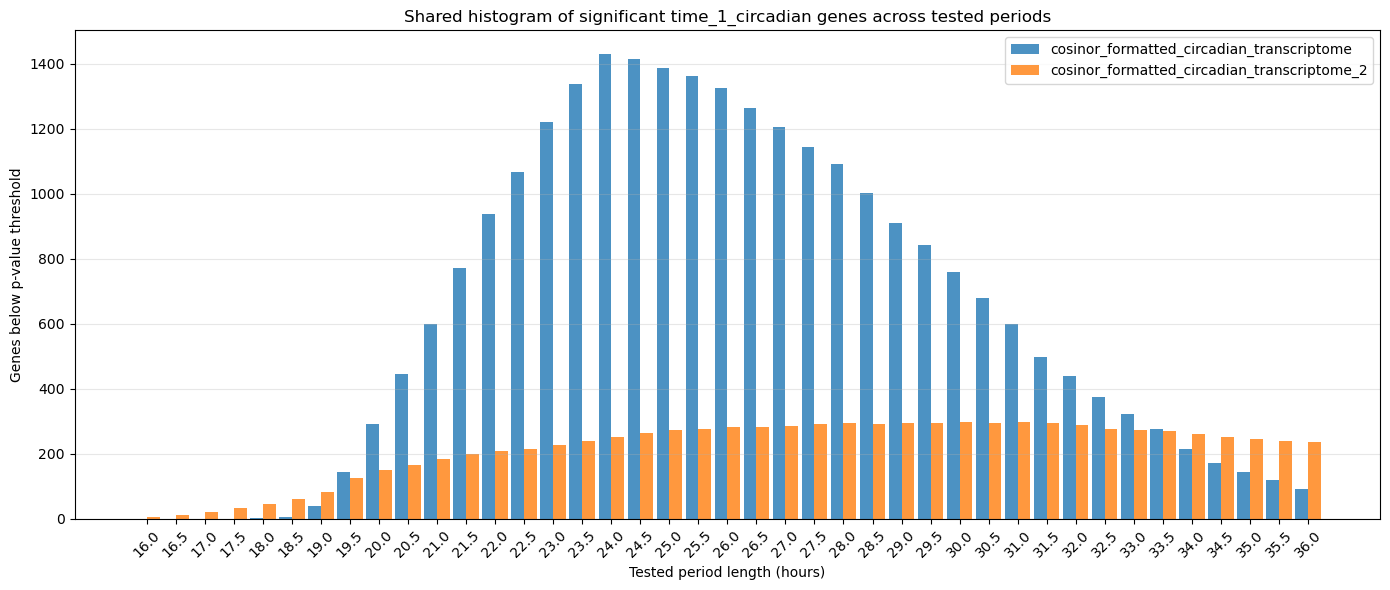

In [29]:
import matplotlib.pyplot as plt

plot_period_scan_summary = period_scan_summary.copy()
plot_period_scan_summary_2 = period_scan_summary_2.copy()

bar_width = 0.22
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    plot_period_scan_summary["period_hours"] - bar_width / 2,
    plot_period_scan_summary["genes_below_pvalue_threshold"],
    width=bar_width,
    label="cosinor_formatted_circadian_transcriptome",
    alpha=0.8,
)
ax.bar(
    plot_period_scan_summary_2["period_hours"] + bar_width / 2,
    plot_period_scan_summary_2["genes_below_pvalue_threshold"],
    width=bar_width,
    label="cosinor_formatted_circadian_transcriptome_2",
    alpha=0.8,
)

ax.set_xlabel("Tested period length (hours)")
ax.set_ylabel("Genes below p-value threshold")
ax.set_title(
    "Shared histogram of significant time_1_circadian genes across tested periods"
)
ax.set_xticks(plot_period_scan_summary["period_hours"])
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()